In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SequentialSampler, RandomSampler

from einops import rearrange
from functools import partial

import matplotlib.pyplot as plt
import logging
import copy
import numpy as np

import math
import os, json
from typing import List,Tuple,Dict

import sys

sys.path.append(os.path.abspath('../ai4flow/acdm'))

from turbpred.data_transformations import Transforms
from turbpred.model_diffusion import DiffusionModel
from turbpred.params import DataParams
from turbpred.model import PredictionModel
from turbpred.logger import Logger
from turbpred.params import DataParams, TrainingParams, LossParams, ModelParamsEncoder, ModelParamsDecoder, ModelParamsLatent
from turbpred.turbulence_dataset import TurbulenceDataset
from turbpred.v2d_transformations import Transforms
from turbpred.loss import PredictionLoss
from turbpred.loss_history import LossHistory
from turbpred.trainer_diffusion import TrainerDiffusion, TesterDiffusion


2024-05-22 15:11:07.429130: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-22 15:11:07.464782: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-22 15:11:08.016901: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Data Handling and Loading

Next, we prepare a class to handle and load the downloaded data set, as well as a data transformations class to handle the data normalization. Mean and standard deviation values are precomputed constants for any given data set.

In [5]:
from turbpred.v2d_dataset import V2dDataset

# index for v2d dataset range: [54452, 99999]

trainSet = V2dDataset(name="V2D dataset",
                     dataDir="/home/chunyang/projects/DDPM4Science/data/v2d",
                     idx_range=[54452, 90888],
                     sequenceLength=[3, 2], rey=1)

# dataset = V2dDataset(name="V2D dataset",
#                      dataDir="/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/",
#                      idx_range=[10, 54459],
#                      sequenceLength=[3, 2])

trainSet[0];

Loading data from 	 /home/chunyang/projects/DDPM4Science/data/v2d
Loading completed. Files loaded: 	36436
Loading completed. Files loaded: 	6072

Dataset info detail:
	 Sequence length of each sample: 3
	 Sequence skiping samples of: 2


In [4]:
trainSet[0]["data"].shape

(3, 4, 128, 64)

In [9]:
type(trainSet[0]["obsMask"])

numpy.ndarray

(128, 64)


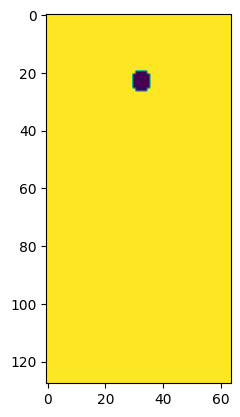

In [6]:
print(trainSet[0]["obsMask"].shape)
plt.imshow(trainSet[0]["obsMask"])

## Training

With all these building blocks out of the way, now its time put them together and train the diffusion model. You can choose to either continue training for a few epochs from the provided model checkpoint (takes less than a minute for 10 epochs), or train the model from scratch on the small examplary data set (takes about half an hour for 1000 epochs). Note that the prediction quality and diversity for training the model from scratch will be noticeably worse, due to limited amount of data available here.

Feel free to skip this step entirely, if you don't want to train the network. You can directly continue with the sampling below, by using the pre-trained checkpoint.

In [4]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Training device: %s" % device)

p_d = DataParams(batch=32, augmentations=["normalize"], sequenceLength=[3,2], randSeqOffset=True,
            dataSize=[128,64], dimension=2, simFields=["pres"], simParams=["rey"], normalizeMode="incMixed")

# trainSet = TurbulenceDataset("Training", ["data"], filterTop=["128_inc"], filterSim=[(10,81)], filterFrame=[(800,1300)],
#                 sequenceLength=[p_d.sequenceLength], randSeqOffset=p_d.randSeqOffset, simFields=p_d.simFields, simParams=p_d.simParams, printLevel="sim")


transTrain = Transforms()
trainSet.transform = transTrain

trainSet.printDatasetInfo()
trainSampler = RandomSampler(trainSet)
#trainSampler = SequentialSampler(trainSet)
trainLoader = DataLoader(trainSet, sampler=trainSampler,
                    batch_size=p_d.batch, drop_last=True, num_workers=4)


Training device: cuda:0
Dataset info detail:
	 Sequence length of each sample: 3
	 Sequence skiping samples of: 2


In [5]:
trainSet[1]["data"].shape

torch.Size([3, 4, 128, 64])

In [6]:
trainSet[1].keys()

dict_keys(['data', 'simParameters', 'allParameters', 'path', 'obsMask'])

In [7]:
trainSet[1]["simParameters"]

array([[1.],
       [1.],
       [1.]], dtype=float32)

In [8]:
trainSet[1]["allParameters"]

{'Reynolds Number': array([1., 1., 1.], dtype=float32),
 'Mach Number': array([0., 0., 0.], dtype=float32),
 'Drag Coefficient': array([0., 0., 0.], dtype=float32),
 'Lift Coefficient': array([0., 0., 0.], dtype=float32),
 'Z Slice': array([0., 0., 0.], dtype=float32)}

In [9]:
trainSet[1]["path"]

['/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_54458.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_54460.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_54462.npy']

In [10]:
trainSet[1]["obsMask"].shape

torch.Size([128, 64])

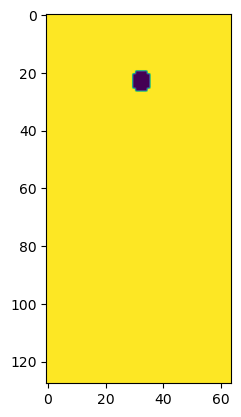

In [11]:
plt.imshow(trainSet[1]["obsMask"])

seq:  0


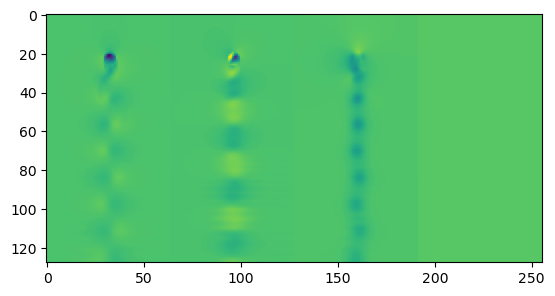

seq:  1


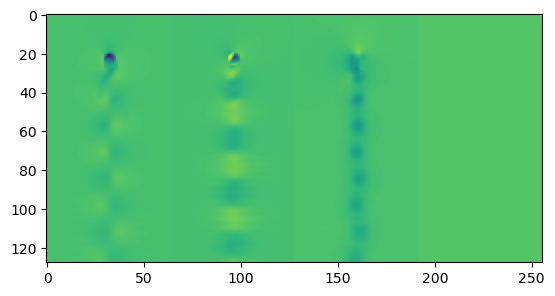

seq:  2


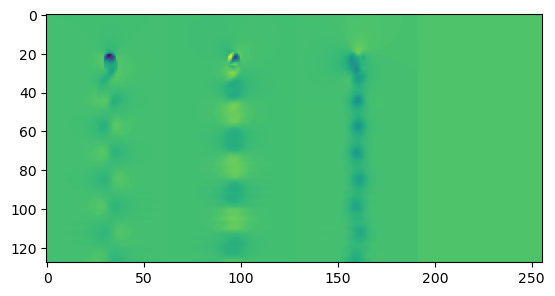

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [12]:
idx = 20
d = trainSet[idx]["data"]

for i in range(d.shape[0]):
    print("seq: ", i)
    plt.imshow(rearrange(d[i], "c h w -> h (c w)"))
    plt.show()

# torch.allclose(d[0, -1, :, :], torch.tensor(0.))
print(d[0, -1, :, :])

In [13]:
!pwd

/data_sdc/wcy/autoreg-pde-diffusion


In [12]:
startFromCheckpoint = True
useGPU = True
gpuID = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = gpuID

# pretrainPath = "/home/chunyang/projects/autoreg-pde-diffusion/models/models_inc/128_acdm-r20_00/Model.pth"
pretrainPath = ""


p_l = LossParams()
p_me = None
p_md = ModelParamsDecoder(arch="direct-ddpm+Prev", diffSteps=20, diffSchedule="linear", diffCondIntegration="noisy", trainingNoise=0.0)
p_ml = None
if startFromCheckpoint:
    p_t = TrainingParams(epochs=3, lr=0.001)
else:
    p_t = TrainingParams(epochs=3100, lr=0.0001)

model = PredictionModel(p_d, p_t, p_l, p_me, p_md, p_ml,
                        pretrainPath="" if not startFromCheckpoint else pretrainPath,
                        useGPU=useGPU)
model.printModelInfo()

Weights Trainable (All): 6981300 (6981300)      Dec: 6981300 (6981300)   
PredictionModel(
  (modelDecoder): DiffusionModel(
    (unet): Unet(
      (init_conv): Conv2d(12, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (time_mlp): Sequential(
        (0): SinusoidalPositionEmbeddings()
        (1): Linear(in_features=128, out_features=512, bias=True)
        (2): GELU()
        (3): Linear(in_features=512, out_features=512, bias=True)
      )
      (downs): ModuleList(
        (0): ModuleList(
          (0): ConvNextBlock(
            (mlp): Sequential(
              (0): GELU()
              (1): Linear(in_features=512, out_features=84, bias=True)
            )
            (ds_conv): Conv2d(84, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=84)
            (net): Sequential(
              (0): GroupNorm(1, 84, eps=1e-05, affine=True)
              (1): Conv2d(84, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (2): GELU()
           

In [15]:
# optimizer = torch.optim.Adam(model.parameters(), lr=p_t.lr, weight_decay=p_t.weightDecay)
# logger = Logger("ACDM", addNumber=True)
# logger.setup(model, optimizer)
# trainHistory = LossHistory("_train", "Training", logger.tfWriter, len(trainLoader),
#                                     0, 1, printInterval=1, logInterval=1, simFields=p_d.simFields)


# trainer = TrainerDiffusion(model, trainLoader, optimizer, trainHistory, logger.tfWriter, p_t)

# print('Starting Training')
# logger.saveTrainState(0)


# for epoch in range(0, p_t.epochs):
#     trainer.trainingStep(epoch)
#     logger.saveTrainState(epoch)

#     trainHistory.updateAccuracy([p_d,p_t,p_l,p_me,p_md,p_ml], [], epoch==p_t.epochs-1)


## Inference

We can now sample the trained diffusion model to create probabilistic predictions for a test set of flow trajectories. Here, we only use two sequences of 60 steps from the $\textit{Ma}=0.7$ data set, at a different physical time than the training data above. We store both predictions and ground truth in tensors with shape $(samples \times sequences \times sequenceLength \times channels \times sizeX \times sizeY)$, that are used for the visualization below.

In [13]:
# get: 1. testSet, testTransformer, testSampler and testLoader.
dataTransformationFieldIndices = [0,1,3,4]

# testSet = TurbulenceDataset("Test Low Reynolds 100-200", ["data"], filterTop=["128_inc"], filterSim=[[0, 82,84,86,88,90]],
#                 filterFrame=[(1000,1150)], sequenceLength=[[60,2]], simFields=["pres"], simParams=["rey"], printLevel="sim")
testSet = V2dDataset(name="V2D dataset",
                     dataDir="/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/",
                     idx_range=[90888, 91488],
                     sequenceLength=[300, 2], rey=1)

testTransformations = Transforms()

testSet.transform = testTransformations

testSampler = SequentialSampler(testSet)
testLoader = DataLoader(testSet, sampler=testSampler, batch_size=len(testSet), drop_last=False)


Loading data from 	 /home/chunyang/projects/autoreg-pde-diffusion/data/v2d/
Loading completed. Files loaded: 	600
Loading completed. Files loaded: 	1

Dataset info detail:
	 Sequence length of each sample: 300
	 Sequence skiping samples of: 2


In [14]:
testSet.__len__()

1

In [15]:
testSet[0]["path"]

['/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90888.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90890.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90892.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90894.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90896.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90898.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90900.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90902.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90904.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90906.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90908.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_0_90910.npy',
 '/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/vort2d_

In [16]:
testSet[0].keys()

dict_keys(['data', 'simParameters', 'allParameters', 'path', 'obsMask'])

In [17]:
# sample for dataset and model inference
if startFromCheckpoint:
    model = PredictionModel.load("/home/chunyang/projects/autoreg-pde-diffusion/runs/2D_Inc/128_acdm-r20_ours_01/Model.pth", useGPU=True)
model.eval()
model.to(device)

evalOptions = {"numEvals": 1,
    "sequentialEvalRuns": {"lowRey": True, "highRey": True, "varReyIn": True},
    "samplingMode": "ddpm",
    "posteriorSampling": "random",
    "initialSampling": "random",
    "conditioningIntegration": "noisy"
},

if isinstance(model.modelDecoder, DiffusionModel):
    if "samplingMode" in evalOptions:
        model.modelDecoder.inferenceSamplingMode = evalOptions["samplingMode"]
    if "posteriorSampling" in evalOptions:
        model.modelDecoder.inferencePosteriorSampling = evalOptions["posteriorSampling"]
    if "initialSampling" in evalOptions:
        model.modelDecoder.inferenceInitialSampling = evalOptions["initialSampling"]
    if "conditioningIntegration" in evalOptions:
        model.modelDecoder.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

elif isinstance(model.modelDecoder, torch.nn.ModuleList):
    for module in model.modelDecoder:
        if isinstance(module, DiffusionModel):
            if "samplingMode" in evalOptions:
                module.inferenceSamplingMode = evalOptions["samplingMode"]
            if "posteriorSampling" in evalOptions:
                module.inferencePosteriorSampling = evalOptions["posteriorSampling"]
            if "initialSampling" in evalOptions:
                module.inferenceInitialSampling = evalOptions["initialSampling"]
            if "conditioningIntegration" in evalOptions:
                module.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

with torch.no_grad():
    predSamples = []
    for s, sample in enumerate(testLoader, 0):
        data = sample["data"].to(device)
        simParameters = sample["simParameters"].to(device) if type(sample["simParameters"]) is not dict else None
        prediction, _, _ = model(data, simParameters)
        print("prediction shape before double unsqueeze: ", prediction.shape)
        prediction = prediction.unsqueeze(0).unsqueeze(0)
        print("prediction shape after double unsqueeze: ", prediction.shape)
        predSamples += [prediction.cpu().numpy()]

    predSamples = np.concatenate(predSamples, axis=2)
    print("sampling finished")


Loading model from /home/chunyang/projects/autoreg-pde-diffusion/runs/2D_Inc/128_acdm-r20_ours_01/Model.pth
prediction shape before double unsqueeze:  torch.Size([1, 300, 4, 128, 64])
prediction shape after double unsqueeze:  torch.Size([1, 1, 1, 300, 4, 128, 64])
sampling finished


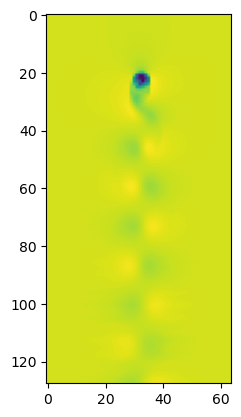

In [18]:
idx = 0
plt.imshow(predSamples[0][0, 0, idx, 0, :, :])

## Prediction Visualizations

After the sampling, we can analyze the ground truth flow trajectory and the samples generated by ACDM. Let's start with a direct visualization of the predictions.

In [19]:
print(predSamples[0].shape)

(1, 1, 300, 4, 128, 64)


In [22]:
data = predSamples[0][0, 0, i, 0, :, :]
plt.imshow(data)
print(np.min(data), np.max(data))
data_expand = rearrange(predSamples[0][0, 0, i, :, :, :], 'c h w -> h (c w)')
print(np.min(data_expand), np.max(data_expand))

NameError: name 'i' is not defined

In [ ]:
# pred_idx = 0

# for i in range(predSamples[0].shape[2]):
#     # plt.imshow(rearrange(prediction[pred_idx, i, :, :, :].cpu().numpy(), 'c h w -> h (c w)'))
#     plt.imshow(rearrange(predSamples[0][0, pred_idx, i, :, :, :], 'c h w -> h (c w)'))
#     # plt.imshow(predSamples[0][0, pred_idx, i, 2, :, :])
#     plt.show()

### Load ground truth sample serial and prediction serial

In [23]:
predSamples[0].shape

(1, 1, 300, 4, 128, 64)

In [24]:
testSet[0]["data"].shape, testSet.__len__()

(torch.Size([300, 4, 128, 64]), 1)

In [25]:
idx_to_vis = 0

pred = predSamples[0][0, idx_to_vis, :, :, :]
ground = testSet[idx_to_vis]["data"].cpu().numpy()

In [26]:
pred.shape, ground.shape

((300, 4, 128, 64), (300, 4, 128, 64))

In [31]:
from functools import partial
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns

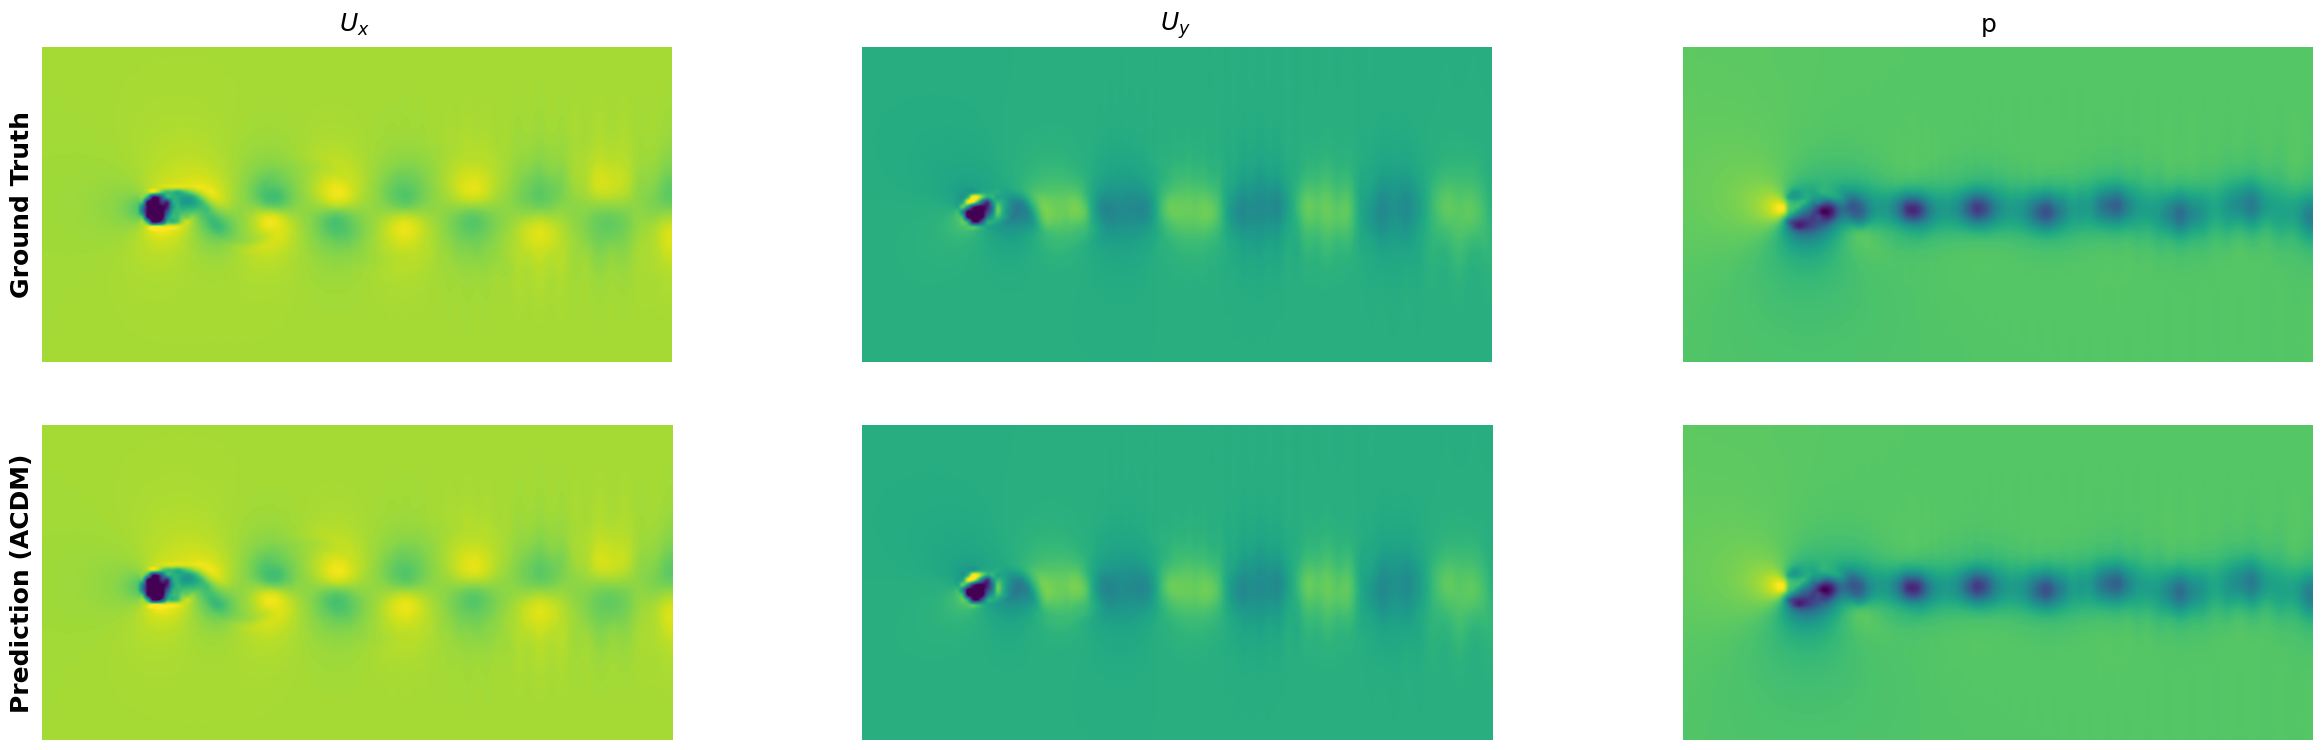

In [35]:
fig, axs = plt.subplots(2, 3, figsize=(30, 9))  # Adjust the figure size as needed

def plot_frame(ground, pred, axs, frame_idx):

    images = []
    for ax in axs.flat:
        ax.clear()
        ax.axis('off')
    i = frame_idx
    # ground_frame
    gf = ground[i, :, :, :]
    ug, vg, pg, _ = gf.clip(-12, 8)
    images.append(axs[0][0].imshow(ug.T, interpolation="catrom"))
    images.append(axs[0][1].imshow(vg.T, interpolation="catrom"))
    images.append(axs[0][2].imshow(pg.T, interpolation="catrom"))
    axs[0][0].text(-0.05, 0.5, 'Ground Truth', va='center', rotation='vertical',
                   transform=axs[0][0].transAxes, fontsize=18, fontweight="bold")
    axs[0][0].text(60, -5, '$U_{x}$', va='center', fontsize=18)
    axs[0][1].text(60, -5, '$U_{y}$', va='center', fontsize=18)
    axs[0][2].text(60, -5, 'p', va='center', fontsize=18)
    # prediction frame
    pf = pred[i, :, :, :]
    up, vp, pp, _ = pf.clip(-12, 8)
    images.append(axs[1][0].imshow(up.T, interpolation="catrom"))
    images.append(axs[1][1].imshow(vp.T, interpolation="catrom"))
    images.append(axs[1][2].imshow(pp.T, interpolation="catrom"))
    axs[1][0].text(-0.05, 0.5, 'Prediction (ACDM)', va='center', rotation='vertical',
                   transform=axs[1][0].transAxes, fontsize=18, fontweight="bold")
    return fig

update = partial(plot_frame, ground, pred, axs)

plot_frame(ground, pred, axs, 0)
anim = FuncAnimation(fig, update, frames=300, interval=30)
HTML(anim.to_html5_video())


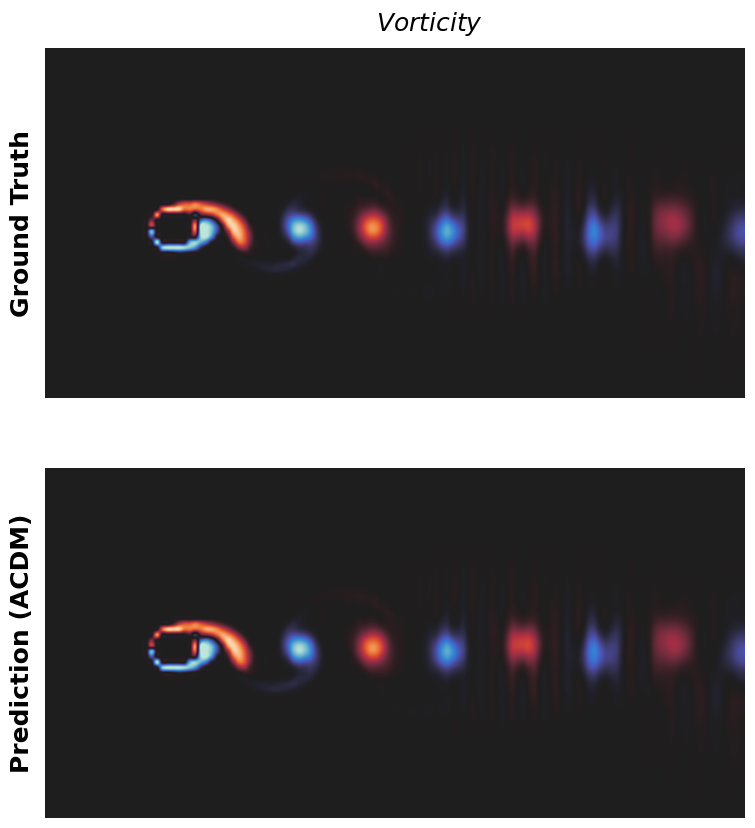

In [64]:
bfig, axs = plt.subplots(2, 1, figsize=(10, 10))  # Adjust the figure size as needed

def plot_frame(ground, pred, axs, frame_idx):
    for ax in axs.flat:
        ax.clear()
        ax.axis('off')
    i = frame_idx
    # ground_frame
    gf = ground[i, :, :, :]
    ug, vg, pg, _ = gf
    vxDx, vxDy = np.gradient(ug)
    vyDx, vyDy = np.gradient(vg)
    vort = vyDx - vxDy
    vort = vort.clip(-3, 3)
    axs[0].imshow(testSet[0]["obsMask"].T * vort.T, interpolation="catrom", cmap="icefire")

    axs[0].text(-0.05, 0.5, 'Ground Truth', va='center', rotation='vertical',
                   transform=axs[0].transAxes, fontsize=18, fontweight="bold")
    axs[0].text(60, -5, '$Vorticity$', va='center', fontsize=18)
    # prediction frame
    pf = pred[i, :, :, :]
    up, vp, pp, _ = pf
    vxDx, vxDy = np.gradient(up)
    vyDx, vyDy = np.gradient(vp)
    vort = vyDx - vxDy
    vort = vort.clip(-3, 3)
    axs[1].imshow(testSet[0]["obsMask"].T * vort.T, interpolation="catrom", cmap="icefire")
    axs[1].text(-0.05, 0.5, 'Prediction (ACDM)', va='center', rotation='vertical',
                   transform=axs[1].transAxes, fontsize=18, fontweight="bold")
    return fig

update = partial(plot_frame, ground, pred, axs)

plot_frame(ground, pred, axs, 0)
anim = FuncAnimation(fig, update, frames=300, interval=30)
HTML(anim.to_html5_video())


In [29]:
import seaborn as sns

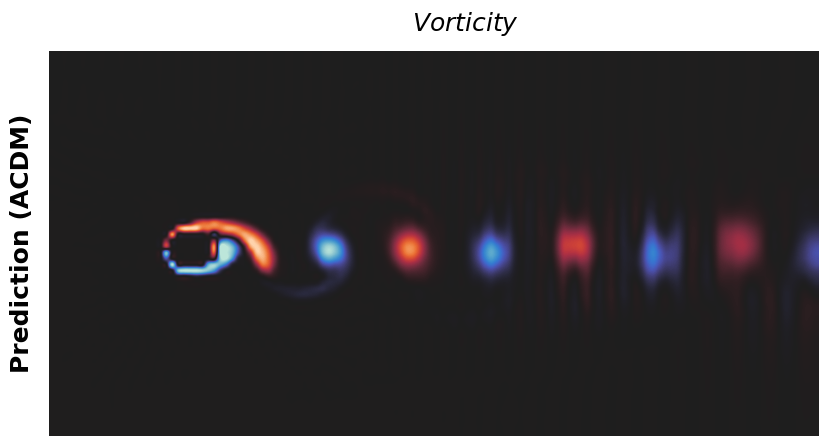

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))  # Adjust the figure size as needed

def plot_frame(ground, pred, ax, frame_idx):
    i = frame_idx
    # print(ax)
    ax.clear()
    ax.axis('off')
    ax.text(60, -5, '$Vorticity$', va='center', fontsize=18)
    # prediction frame
    pf = pred[i, :, :, :]
    up, vp, pp, _ = pf
    vxDx, vxDy = np.gradient(up)
    vyDx, vyDy = np.gradient(vp)
    vort = vyDx - vxDy
    vort = vort.clip(-3, 3)
    ax.imshow(testSet[0]["obsMask"].T * vort.T, interpolation="catrom", cmap="icefire")
    ax.text(-0.05, 0.5, 'Prediction (ACDM)', va='center', rotation='vertical',
                   transform=ax.transAxes, fontsize=18, fontweight="bold")
    return fig

update = partial(plot_frame, ground, pred, ax)

plot_frame(ground, pred, ax, 0)
anim = FuncAnimation(fig, update, frames=300, interval=30)
HTML(anim.to_html5_video())

In [ ]:
anim.save("ours.mp4")

In [ ]:
import tqdm

def find_mean_and_std(input):
    mean = np.mean(input)
    std = np.std(input)
    return mean, std

u_list = []
v_list = []
p_list = []

for i in tqdm.tqdm(range(len(testSet))):
    u = testSet[i]["data"][0, 0, :, :]
    v = testSet[i]["data"][0, 1, :, :]
    p = testSet[i]["data"][0, 2, :, :]
    u_list.append(u)
    v_list.append(v)
    p_list.append(p)
    
u_mean, u_std = find_mean_and_std(np.stack(u_list).flatten())
v_mean, v_std = find_mean_and_std(np.stack(v_list).flatten())
p_mean, p_std = find_mean_and_std(np.stack(p_list).flatten())

print(u_mean, u_std)
print(v_mean, v_std)
print(p_mean, p_std)

100%|██████████| 1/1 [00:01<00:00,  1.11s/it]

-0.0063063744 1.0816833
0.0043468513 1.103156
-0.050862063 1.0124863


TypeError: min() received an invalid combination of arguments - got (out=NoneType, axis=NoneType, ), but expected one of:
 * ()
 * (Tensor other)
 * (int dim, bool keepdim)
      didn't match because some of the keywords were incorrect: out, axis
 * (name dim, bool keepdim)
      didn't match because some of the keywords were incorrect: out, axis


In [ ]:
testSet[0]["data"][0, 0, :, :].shape

torch.Size([128, 64])

In [ ]:
pred.shape

(300, 4, 128, 64)

In [101]:
def find_mean_and_std(input):
    mean = np.mean(input)
    std = np.std(input)
    return mean, std

u_list = []
v_list = []
p_list = []

for i in tqdm.tqdm(range(pred.shape[0])):
    u = pred[i, 0, :, :]
    v = pred[i, 1, :, :]
    p = pred[i, 2, :, :]
    u_list.append(u)
    v_list.append(v)
    p_list.append(p)
    
u_mean, u_std = find_mean_and_std(np.stack(u_list).flatten())
v_mean, v_std = find_mean_and_std(np.stack(v_list).flatten())
p_mean, p_std = find_mean_and_std(np.stack(p_list).flatten())

print(u_mean, u_std)
print(v_mean, v_std)
print(p_mean, p_std)

NameError: name 'tqdm' is not defined

In [ ]:
u_min = np.min(pred[:, 0, :, :])
u_max = np.max(pred[:, 0, :, :])

v_min = np.min(pred[:, 1, :, :])
v_max = np.max(pred[:, 1, :, :])

p_min = np.min(pred[:, 2, :, :])
p_max = np.max(pred[:, 2, :, :])

print(u_min, u_max)
print(v_min, v_max)
print(p_min, p_max)

-27.310856 2.2760613
-29.892317 13.492775
-9.3238945 3.9018738


In [84]:
pred.shape

(300, 4, 128, 64)

In [86]:
ground.shape

(300, 4, 128, 64)

In [92]:
ground[:, 0, :, :].shape, pred[:, 0, :, :].shape

((300, 128, 64), (300, 128, 64))

In [100]:
loss = torch.nn.MSELoss()
loss(torch.from_numpy(pred[:, 2, :, :]), torch.from_numpy(ground[:, 0, :, :]))

tensor(1.6053)